In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from statsmodels.formula.api import ols
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, completeness_score, homogeneity_score, silhouette_score
from pathlib import Path

<h1> BASELINE </h1>

In [2]:

files = ['dataset/iris.csv', 'dataset/glass.csv', 'dataset/breast-cancer.csv']
n_runs = 50
results = []

for fn in files:
    df = pd.read_csv(fn, header=None)
    target_col = df.columns[-1]
    y = df[target_col]
    X = df.drop(columns=[target_col]).copy()

    drop_cols = []
    for c in list(X.columns):
        s = X[c]
        is_integer_like = pd.api.types.is_numeric_dtype(s) and np.all(np.isclose(s.dropna() % 1, 0))
        is_unique = s.nunique(dropna=False) == len(s)
        is_sequential = is_integer_like and np.all(np.diff(s.to_numpy()) == 1)
        if is_unique and is_sequential:
            drop_cols.append(c)
    if drop_cols:
        X = X.drop(columns=drop_cols)

    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = LabelEncoder().fit_transform(X[c].astype(str))
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.fillna(X.median(numeric_only=True))

    y_enc = LabelEncoder().fit_transform(y.astype(str))
    n_clusters = len(np.unique(y_enc))
    X_scaled = MinMaxScaler().fit_transform(X)

    ari_runs = []
    completeness_runs = []
    homogeneity_runs = []
    silhouette_runs = []

    for run in range(n_runs):
        km = KMeans(n_clusters=n_clusters, random_state=42 + run, n_init=20)
        pred = km.fit_predict(X_scaled)

        ari_runs.append(adjusted_rand_score(y_enc, pred))
        completeness_runs.append(completeness_score(y_enc, pred))
        homogeneity_runs.append(homogeneity_score(y_enc, pred))
        try:
            silhouette_runs.append(silhouette_score(X_scaled, pred))
        except ValueError:
            silhouette_runs.append(np.nan)

    results.append({
        'dataset': fn,
        'rows': len(df),
        'features_used': X.shape[1],
        'label_column_index': int(target_col),
        'dropped_columns': ','.join(map(str, drop_cols)) if drop_cols else '',
        'n_true_classes': n_clusters,
        'n_runs': n_runs,
        'ARI_mean': float(np.mean(ari_runs)),
        'completeness_mean': float(np.mean(completeness_runs)),
        'homogeneity_mean': float(np.mean(homogeneity_runs)),
        'silhouette_mean': float(np.nanmean(silhouette_runs)) if np.any(~np.isnan(silhouette_runs)) else np.nan
    })

res_df = pd.DataFrame(results)
res_df

,dataset,rows,features_used,label_column_index,dropped_columns,n_true_classes,n_runs,ARI_mean,completeness_mean,homogeneity_mean,silhouette_mean
0,dataset/iris.csv,150,4,4,,3,50,0.716342,0.747487,0.736419,0.504319
1,dataset/glass.csv,214,9,9,,6,50,0.166906,0.332429,0.319668,0.379519
2,dataset/breast-cancer.csv,569,30,30,,2,50,0.730175,0.635151,0.611471,0.384549


<h1> IRIS </h1>

In [19]:
df_iris = pd.read_csv("antclust experiment - iris-table.csv")
df_iris = df_iris.drop(labels=["[run number]", "file-name", "[step]"], axis=1)
df_iris = df_iris.rename(columns={"length (remove-duplicates [label-id] of turtles)": "n_clusters"})
df_iris.head()

,initial-meetings-pct,alpha,iterations-multiplier,lambda,threshold,res-ari,res-p,res-r,res-s,n_clusters
0,0.50,0.05,10,0.995,0.01,0.271983,0.721100,0.332418,-0.151007,14
1,0.25,0.00,10,0.995,0.01,0.210535,0.740519,0.298537,-0.193289,19
2,0.10,0.05,10,0.995,0.01,0.254808,0.734652,0.342683,-0.187660,12
3,0.25,0.05,10,0.995,0.01,0.197799,0.721533,0.319415,-0.232543,18
4,1.00,0.00,10,0.995,0.01,0.160231,0.729447,0.287761,-0.245574,21


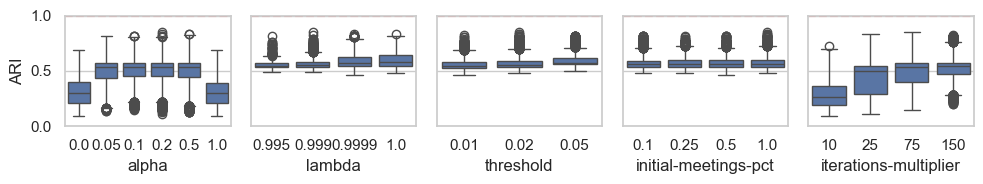

In [20]:
# Set plot style
sns.set_theme(style="whitegrid")

# Filtered dataset
df_iris_filtered = df_iris[(df_iris['alpha'] > 0.0) & (df_iris['alpha'] < 1.0) & (df_iris['iterations-multiplier'] >= 75)].copy()

# parameters to explore visually
params_to_plot_iris = ['alpha', 'lambda', 'threshold', 'initial-meetings-pct', 'iterations-multiplier']

# create 1x5 grid for boxplots (same size as GLASS and BREAST-CANCER)
fig_iris, axes_iris = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
axes_iris = axes_iris.flatten()

for i, param in enumerate(params_to_plot_iris):
    plot_data = df_iris if param == 'alpha' or param == 'iterations-multiplier' else df_iris_filtered
    sns.boxplot(data=plot_data, x=param, y='res-ari', ax=axes_iris[i], whis=2.0)
    axes_iris[i].set_xlabel(param)
    axes_iris[i].set_ylim(0, 1)
    axes_iris[0].set_ylabel('ARI')

    # Red line for perfect target
    axes_iris[i].axhline(1.0, color='red', linestyle='--', alpha=0.5)

#plt.suptitle("Sensitivity Analysis - IRIS", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Top 10 configurations by n_clusters variability:



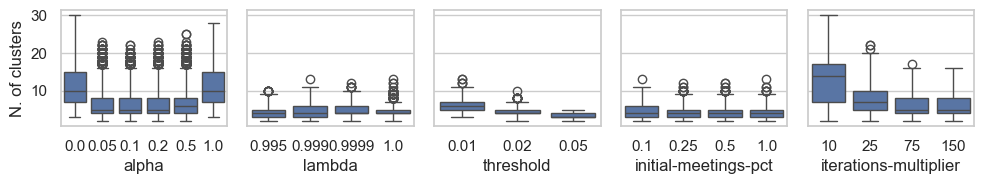

In [17]:
params = ['alpha', 'lambda', 'threshold', 'initial-meetings-pct', 'iterations-multiplier']

# 1) Stability table for n_clusters by full parameter configuration
stability = (
    df_iris.groupby(params)['n_clusters']
    .agg(mean='mean', std='std', min='min', max='max', n='count')
    .reset_index()
    .sort_values('std', ascending=False)
 )

print('Top 10 configurations by n_clusters variability:\n')

# 2) Visual fluctuation of n_clusters for each parameter
fig_nc, axes_nc = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
axes_nc = axes_nc.flatten()

for i, param in enumerate(params):
    plot_data = df_iris if param == 'alpha' or param == 'iterations-multiplier' else df_iris_filtered
    sns.boxplot(data=plot_data, x=param, y='n_clusters', ax=axes_nc[i], whis=2.0)
    axes_nc[i].set_xlabel(param)
    axes_nc[0].set_ylabel('N. of clusters')

#plt.suptitle('n_clusters Fluctuation - IRIS', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

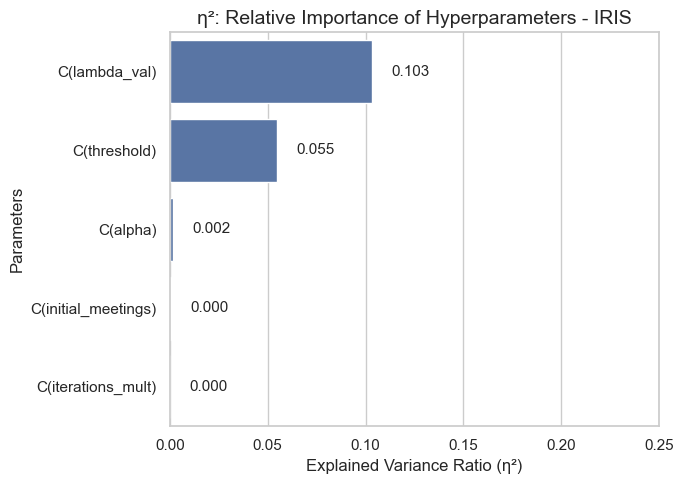

In [18]:
# statsmodels does not accept '-' in column names or reserved words (lambda)
df_anova_iris = df_iris_filtered.rename(columns={
    'res-ari': 'res_ari',
    'initial-meetings-pct': 'initial_meetings',
    'iterations-multiplier': 'iterations_mult',
    'lambda': 'lambda_val'
})

# include all parameters
formula_iris = 'res_ari ~ C(alpha) + C(lambda_val) + C(threshold) + C(initial_meetings) + C(iterations_mult)'
model_iris = ols(formula_iris, data=df_anova_iris).fit()
anova_table_iris = sm.stats.anova_lm(model_iris, typ=2)

# COMPUTE ETA SQUARED (eta^2): parameter variance / total variance
anova_table_iris['eta_sq'] = anova_table_iris['sum_sq'] / anova_table_iris['sum_sq'].sum()

# Remove residual noise and sort from most important to least
eta_sq_data_iris = anova_table_iris.drop(index='Residual', errors='ignore')['eta_sq'].sort_values(ascending=False)

# PLOT: effect size bar chart
plt.figure(figsize=(7, 5))
ax_iris = sns.barplot(x=eta_sq_data_iris.values, y=eta_sq_data_iris.index)

plt.title('η²: Relative Importance of Hyperparameters - IRIS', fontsize=14)
plt.xlabel('Explained Variance Ratio (η²)', fontsize=12)
plt.ylabel('Parameters', fontsize=12)
plt.xlim(0, 0.25)

# Add text labels on bars for readability
for patch in ax_iris.patches:
    width = patch.get_width()
    plt.text(width + 0.01, patch.get_y() + patch.get_height() / 2, f'{width:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [13]:
# aggregated behavior on main drivers for IRIS
driver_params_iris = ['lambda', 'threshold']

# Metrics for mean and standard deviation
metrics_iris = ['res-ari', 'res-p', 'res-r', 'res-s', 'n_clusters']

# compute mean and std
agg_funcs_iris = {m: ['mean', 'std'] for m in metrics_iris}
final_table_iris = df_iris_filtered.groupby(driver_params_iris,as_index=False).agg(agg_funcs_iris)

# round to 3 decimals for readability
final_table_iris = final_table_iris.round(3)

# show top 5 configs by mean ARI
top_configs_iris = final_table_iris.sort_values(by=('res-ari', 'mean'), ascending=False).head(5)

print("Top Aggregated IRIS Configurations (Mean and Std Dev):\n")
display(top_configs_iris)

Top Aggregated IRIS Configurations (Mean and Std Dev):



lambda threshold res-ari         res-p         res-r         res-s         \
                       mean    std   mean    std   mean    std   mean    std   
11  1.000      0.05   0.618  0.068  0.702  0.046  0.695  0.076  0.440  0.063   
8   1.000      0.05   0.611  0.066  0.695  0.046  0.698  0.081  0.439  0.068   
10  1.000      0.02   0.596  0.066  0.720  0.036  0.628  0.056  0.356  0.075   
7   1.000      0.02   0.588  0.065  0.714  0.036  0.630  0.057  0.354  0.081   
5   0.999      0.05   0.585  0.048  0.659  0.049  0.752  0.109  0.466  0.096   

   n_clusters         
         mean    std  
11      3.441  0.559  
8       3.412  0.564  
10      4.581  0.916  
7       4.548  1.003  
5       3.134  0.616

<h1> GLASS </h1>

In [46]:
df_glass = pd.read_csv("antclust experiment - glass-table.csv")
df_glass = df_glass.drop(labels=["[run number]", "file-name", "[step]"], axis=1)
df_glass = df_glass.rename(columns={"length (remove-duplicates [label-id] of turtles)": "n_clusters"})
df_glass.head()

,initial-meetings-pct,alpha,iterations-multiplier,lambda,threshold,res-ari,res-p,res-r,res-s,n_clusters
0,0.5,0.1,75,0.999,0.01,0.193994,0.341175,0.326543,0.062550,9
1,0.5,0.1,75,0.999,0.01,0.200873,0.336355,0.325817,0.072493,8
2,0.5,0.1,75,0.999,0.01,0.161669,0.306803,0.306130,0.051028,9
3,0.5,0.1,75,0.999,0.01,0.163807,0.283433,0.300653,0.130783,8
4,0.5,0.1,75,0.999,0.01,0.204354,0.359523,0.375954,0.129529,7


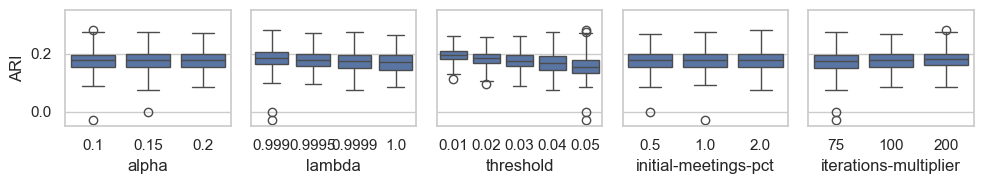

In [47]:
# Set plot style
sns.set_theme(style="whitegrid")

# remove alpha values that do not converge (0 and 1)
df_glass_filtered = df_glass[(df_glass['alpha'] > 0.0) & (df_glass['alpha'] < 1.0)].copy()

# parameters to explore visually
params_to_plot_glass = ['alpha','lambda', 'threshold', 'initial-meetings-pct', 'iterations-multiplier']

# create 2x2 grid for boxplots
fig_glass, axes_glass = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
axes_glass = axes_glass.flatten()

for i, param in enumerate(params_to_plot_glass):
    sns.boxplot(data=df_glass_filtered, x=param, y='res-ari', ax=axes_glass[i], whis=2.0)
    axes_glass[i].set_xlabel(param)
    axes_glass[i].set_ylim(-0.05, 0.35)
    axes_glass[0].set_ylabel('ARI')

    # Red line for perfect target
    axes_glass[i].axhline(1.0, color='red', linestyle='--', alpha=0.5)

#plt.suptitle("Sensitivity Analysis - GLASS", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Top 10 configurations by n_clusters variability - GLASS:



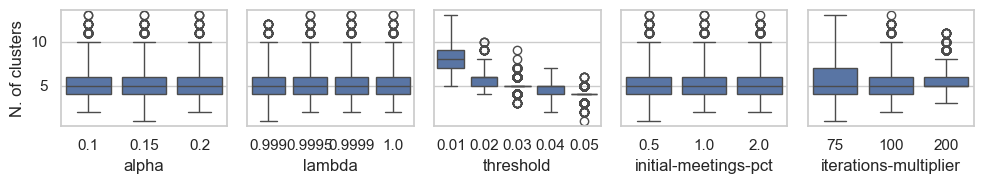

In [48]:
params_glass = ['alpha', 'lambda', 'threshold', 'initial-meetings-pct', 'iterations-multiplier']

# Stability table for n_clusters by full parameter configuration
stability_glass = (
    df_glass.groupby(params_glass)['n_clusters']
    .agg(mean='mean', std='std', min='min', max='max', n='count')
    .reset_index()
    .sort_values('std', ascending=False)
 )

print('Top 10 configurations by n_clusters variability - GLASS:\n')

# Visual fluctuation of n_clusters for each parameter
fig_nc_glass, axes_nc_glass = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
axes_nc_glass = axes_nc_glass.flatten()

for i, param in enumerate(params_glass):
    plot_data = df_glass if param == 'alpha' else df_glass_filtered
    sns.boxplot(data=plot_data, x=param, y='n_clusters', ax=axes_nc_glass[i], whis=2.0)
    axes_nc_glass[i].set_xlabel(param)
    axes_nc_glass[0].set_ylabel('N. of clusters')

#plt.suptitle('n_clusters Fluctuation - GLASS', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

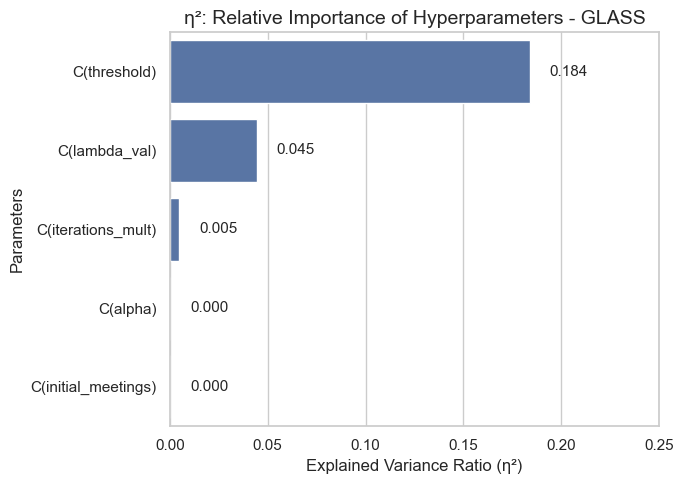

In [65]:
df_glass_filtered = df_glass[(df_glass['alpha'] > 0.0) & (df_glass['alpha'] < 1.0)].copy()

# statsmodels does not accept '-' in column names or reserved words (lambda)
df_anova_glass = df_glass_filtered.rename(columns={
    'res-ari': 'res_ari',
    'initial-meetings-pct': 'initial_meetings',
    'iterations-multiplier': 'iterations_mult',
    'lambda': 'lambda_val'
})

# include all parameters
formula_glass = 'res_ari ~ C(lambda_val) + C(threshold) + C(initial_meetings) + C(iterations_mult) + C(alpha)'
model_glass = ols(formula_glass, data=df_anova_glass).fit()
anova_table_glass = sm.stats.anova_lm(model_glass, typ=2)

# COMPUTE ETA SQUARED (η²): parameter variance / total variance
anova_table_glass['eta_sq'] = anova_table_glass['sum_sq'] / anova_table_glass['sum_sq'].sum()

# Remove residual noise and sort from most important to least
eta_sq_data_glass = anova_table_glass.drop(index='Residual', errors='ignore')['eta_sq'].sort_values(ascending=False)

# effect size bar chart
plt.figure(figsize=(7, 5))
ax_glass = sns.barplot(x=eta_sq_data_glass.values, y=eta_sq_data_glass.index)

plt.title('η²: Relative Importance of Hyperparameters - GLASS', fontsize=14)
plt.xlabel('Explained Variance Ratio (η²)', fontsize=12)
plt.ylabel('Parameters', fontsize=12)
plt.xlim(0, 0.25)  # η² goes from 0 to 1 but here it is much smaller

# Add text labels on bars for readability
for patch in ax_glass.patches:
    width = patch.get_width()
    plt.text(width + 0.01, patch.get_y() + patch.get_height() / 2, f'{width:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [36]:
# aggregated behavior on main parameters for GLASS
driver_params_glass = ['lambda', 'threshold']

# Metrics, mean and standard deviation
metrics_glass = ['res-ari', 'res-p', 'res-r', 'res-s', 'n_clusters']
agg_funcs_glass = {m: ['mean', 'std'] for m in metrics_glass}
final_table_glass = df_glass_filtered.groupby(driver_params_glass,as_index=False).agg(agg_funcs_glass)

# round to 3 decimals for readability
final_table_glass = final_table_glass.round(3)

# show top 5 configs by mean ARI
top_configs_glass = final_table_glass.sort_values(by=('res-ari', 'mean'), ascending=False).head(5)

print("Top Aggregated GLASS Configurations (Mean and Std Dev):\n")
display(top_configs_glass)

Top Aggregated GLASS Configurations (Mean and Std Dev):



lambda threshold res-ari         res-p         res-r         res-s         \
                       mean    std   mean    std   mean    std   mean    std   
0   0.999      0.01   0.198  0.021  0.350  0.033  0.345  0.026  0.079  0.066   
5   1.000      0.01   0.196  0.021  0.354  0.033  0.344  0.025  0.080  0.064   
15  1.000      0.01   0.193  0.021  0.372  0.033  0.345  0.025  0.078  0.059   
10  1.000      0.01   0.192  0.019  0.362  0.032  0.343  0.023  0.080  0.053   
1   0.999      0.02   0.187  0.022  0.313  0.032  0.338  0.030  0.102  0.063   

   n_clusters         
         mean    std  
0       8.060  1.413  
5       7.991  1.466  
15      8.478  1.446  
10      8.161  1.532  
1       5.961  0.971

<h1> BREAST-CANCER </h1>

In [66]:
df_breast = pd.read_csv("antclust experiment - breast-cancer-table.csv")
df_breast = df_breast.drop(labels=["[run number]", "file-name", "[step]"], axis=1)
df_breast = df_breast.rename(columns={"length (remove-duplicates [label-id] of turtles)": "n_clusters"})
df_breast.head()

,initial-meetings-pct,alpha,iterations-multiplier,lambda,threshold,res-ari,res-p,res-r,res-s,n_clusters
0,0.5,0.2,75,0.999,0.01,0.581177,0.663633,0.394844,-0.072712,5
1,0.5,0.2,75,0.999,0.01,0.567983,0.588154,0.296057,0.108056,8
2,0.5,0.2,75,0.999,0.01,0.477599,0.594759,0.266039,-0.153731,10
3,0.5,0.2,75,0.999,0.01,0.409442,0.586361,0.224608,-0.184036,12
4,0.5,0.2,75,0.999,0.01,0.592224,0.690812,0.336275,-0.011110,9


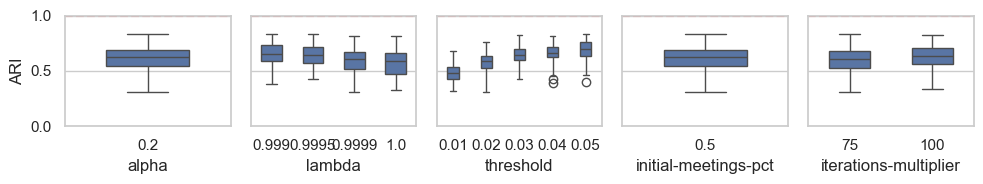

In [67]:
# Set plot style
sns.set_theme(style="whitegrid")

# remove alpha values that do not converge (0 and 1)
df_breast_filtered = df_breast[(df_breast['alpha'] > 0.0) & (df_breast['alpha'] < 1.0)].copy()

# parameters to explore visually
params_to_plot_breast = ['alpha','lambda', 'threshold', 'initial-meetings-pct', 'iterations-multiplier']

# create 1x5 grid for boxplots
fig_breast, axes_breast = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
axes_breast = axes_breast.flatten()

for i, param in enumerate(params_to_plot_breast):
    box_width = 0.35 if i == 2 else 0.5
    sns.boxplot(data=df_breast_filtered, x=param, y='res-ari', ax=axes_breast[i], width=box_width, whis=2.0)
    axes_breast[i].set_xlabel(param)
    axes_breast[i].set_ylim(0, 1)
    axes_breast[0].set_ylabel('ARI')

    # Red line for perfect target
    axes_breast[i].axhline(1.0, color='red', linestyle='--', alpha=0.5)

#plt.suptitle("Sensitivity Analysis - BREAST-CANCER", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Top 10 configurations by n_clusters variability - BREAST-CANCER:



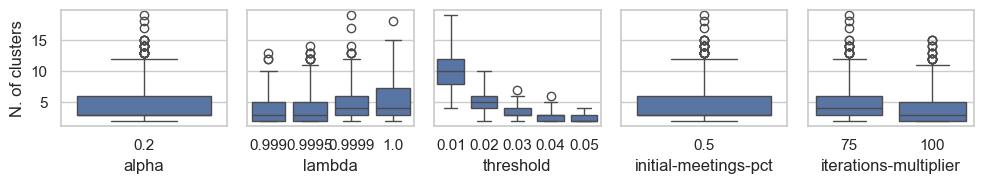

In [61]:
params_breast = ['alpha', 'lambda', 'threshold', 'initial-meetings-pct', 'iterations-multiplier']

# Stability table for n_clusters by full parameter configuration
stability_breast = (
    df_breast.groupby(params_breast)['n_clusters']
    .agg(mean='mean', std='std', min='min', max='max', n='count')
    .reset_index()
    .sort_values('std', ascending=False)
 )

print('Top 10 configurations by n_clusters variability - BREAST-CANCER:\n')

# Visual fluctuation of n_clusters for each parameter
fig_nc_breast, axes_nc_breast = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
axes_nc_breast = axes_nc_breast.flatten()

for i, param in enumerate(params_breast):
    plot_data = df_breast if param == 'alpha' else df_breast_filtered
    sns.boxplot(data=plot_data, x=param, y='n_clusters', ax=axes_nc_breast[i], whis=2.0)
    axes_nc_breast[i].set_xlabel(param)
    axes_nc_breast[0].set_ylabel('N. of clusters')

#plt.suptitle('n_clusters Fluctuation - BREAST-CANCER', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

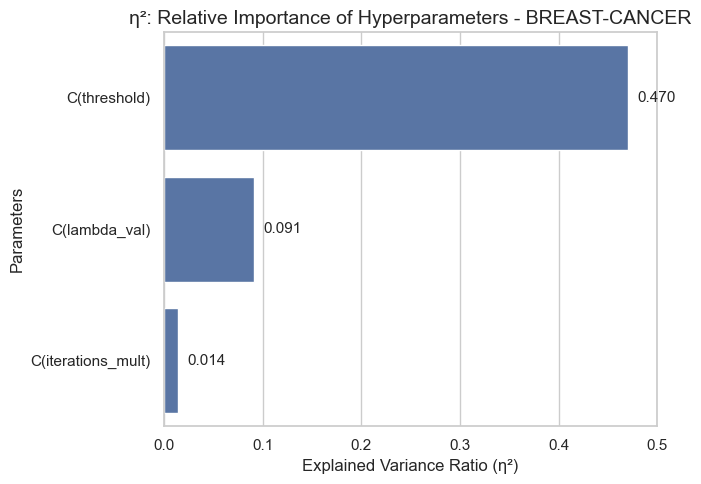

In [68]:
# statsmodels does not accept '-' in column names or reserved words (lambda)
df_anova_breast = df_breast_filtered.rename(columns={
    'res-ari': 'res_ari',
    'initial-meetings-pct': 'initial_meetings',
    'iterations-multiplier': 'iterations_mult',
    'lambda': 'lambda_val'
})

# exclude constant parameters (alpha and initial_meetings)
formula_breast = 'res_ari ~ C(lambda_val) + C(threshold) + C(iterations_mult)'
model_breast = ols(formula_breast, data=df_anova_breast).fit()
anova_table_breast = sm.stats.anova_lm(model_breast, typ=2)

# parameter variance / total variance
anova_table_breast['eta_sq'] = anova_table_breast['sum_sq'] / anova_table_breast['sum_sq'].sum()

# Remove residual noise and sort from most important to least
eta_sq_data_breast = anova_table_breast.drop(index='Residual', errors='ignore')['eta_sq'].sort_values(ascending=False)

# effect size bar chart
plt.figure(figsize=(7, 5))
ax_breast = sns.barplot(x=eta_sq_data_breast.values, y=eta_sq_data_breast.index)

plt.title('η²: Relative Importance of Hyperparameters - BREAST-CANCER', fontsize=14)
plt.xlabel('Explained Variance Ratio (η²)', fontsize=12)
plt.ylabel('Parameters', fontsize=12)
plt.xlim(0, 0.5)  # η² goes from 0 to 1

# Add text labels on bars for readability
for patch in ax_breast.patches:
    width = patch.get_width()
    plt.text(width + 0.01, patch.get_y() + patch.get_height() / 2, f'{width:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [63]:
# aggregated behavior on main drivers for BREAST-CANCER
driver_params_breast = ['lambda', 'threshold']

# Metrics for mean and standard deviation
metrics_breast = ['res-ari', 'res-p', 'res-r', 'res-s', 'n_clusters']

# compute mean and std
agg_funcs_breast = {m: ['mean', 'std'] for m in metrics_breast}
final_table_breast = df_breast_filtered.groupby(driver_params_breast,as_index=False).agg(agg_funcs_breast)

# round to 3 decimals for readability
final_table_breast = final_table_breast.round(3)

# show top 5 configs by mean ARI
top_configs_breast = final_table_breast.sort_values(by=('res-ari', 'mean'), ascending=False).head(5)

print("Top Aggregated BREAST-CANCER Configurations (Mean and Std Dev):\n")
display(top_configs_breast)

Top Aggregated BREAST-CANCER Configurations (Mean and Std Dev):



lambda threshold res-ari         res-p         res-r         res-s         \
                       mean    std   mean    std   mean    std   mean    std   
4   0.999      0.05   0.725  0.069  0.635  0.059  0.612  0.106  0.489  0.076   
9   1.000      0.05   0.700  0.075  0.627  0.060  0.571  0.123  0.453  0.111   
14  1.000      0.05   0.696  0.078  0.619  0.061  0.588  0.114  0.478  0.118   
2   0.999      0.03   0.695  0.073  0.633  0.050  0.541  0.126  0.390  0.139   
8   1.000      0.04   0.687  0.052  0.621  0.047  0.538  0.094  0.424  0.105   

   n_clusters         
         mean    std  
4       2.275  0.452  
9       2.500  0.679  
14      2.350  0.622  
2       2.850  0.949  
8       2.650  0.662